In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from mpl_toolkits.mplot3d import Axes3D
import subprocess

matplotlib.rcParams.update({"axes.grid": True})
# matplotlib.rcParams.keys()

Blocking by Jonsson

In [ ]:
# Common imports
import os

# Where to save the figures and data files
DATA_ID = "Results/EnergyMin"

def data_path(dat_id):
    return os.path.join(DATA_ID, dat_id)

infile = open(data_path("Energies.dat"),'r')

from numpy import log2, zeros, mean, var, sum, loadtxt, arange, array, cumsum, dot, transpose, diagonal, sqrt
from numpy.linalg import inv

def block(x):
    # preliminaries
    n = len(x)
    d = int(log2(n))
    s, gamma = zeros(d), zeros(d)
    mu = mean(x)

    # estimate the auto-covariance and variances 
    # for each blocking transformation
    for i in arange(0,d):
        n = len(x)
        # estimate autocovariance of x
        gamma[i] = (n)**(-1)*sum( (x[0:(n-1)]-mu)*(x[1:n]-mu) )
        # estimate variance of x
        s[i] = var(x)
        # perform blocking transformation
        x = 0.5*(x[0::2] + x[1::2])
   
    # generate the test observator M_k from the theorem
    M = (cumsum( ((gamma/s)**2*2**arange(1,d+1)[::-1])[::-1] )  )[::-1]

    # we need a list of magic numbers
    q =array([6.634897,9.210340, 11.344867, 13.276704, 15.086272, 16.811894, 18.475307, 20.090235, 21.665994, 23.209251, 24.724970, 26.216967, 27.688250, 29.141238, 30.577914, 31.999927, 33.408664, 34.805306, 36.190869, 37.566235, 38.932173, 40.289360, 41.638398, 42.979820, 44.314105, 45.641683, 46.962942, 48.278236, 49.587884, 50.892181])

    # use magic to determine when we should have stopped blocking
    for k in arange(0,d):
        if(M[k] < q[k]):
            break
    if (k >= d-1):
        print("Warning: Use more data")
    return mu, s[k]/2**(d-k)


x = loadtxt(infile)
(mean, var) = block(x) 
std = sqrt(var)
import pandas as pd
from pandas import DataFrame
data ={'Mean':[mean], 'STDev':[std]}
frame = pd.DataFrame(data,index=['Values'])
print(frame)

In [2]:
compile = subprocess.run(
    ["./compile_project"],
    capture_output=True,
    text=True
)

print(compile.stdout)
print(compile.stderr)

-- Configuring done (0.0s)
-- Generating done (0.0s)
-- Build files have been written to: /home/davide/GitHub/computational_physics_2_2026/variational-monte-carlo-fys4411-DC2026/build
[  5%] Linking CXX executable vmc
[100%] Built target vmc

mkdir: cannot create directory ‘build’: File exists



Analytic if available

In [3]:
# result = subprocess.run(
#     ["./vmc", "true"],
#     capture_output=True,
#     text=True
# )

# print(result.stdout)
# print(result.stderr)

Text(0.5, 0, '$\\alpha$')

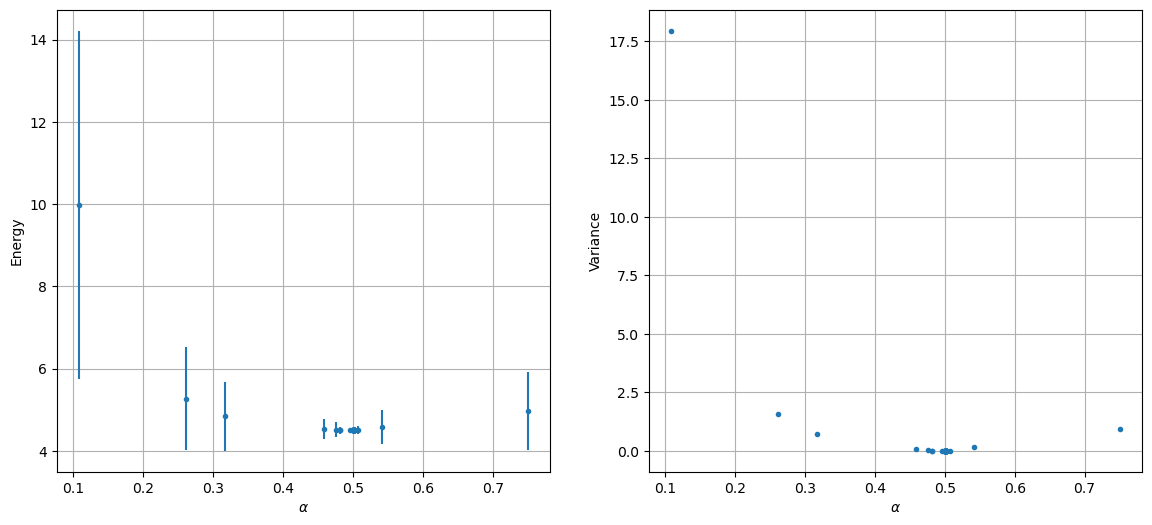

In [4]:
%matplotlib inline

file = np.loadtxt("iofiles/log.csv", delimiter=',')
file = np.transpose(file)
parameters = file[:file.shape[0] - 5, :]
energy = file[file.shape[0] - 5, :]
variance = file[file.shape[0] - 4, :]
error = file[file.shape[0] - 3, :]

fig = plt.figure(figsize=(14,6))
gs = fig.add_gridspec(1,2)
ax = fig.add_subplot(gs[0, 0])
ax.errorbar(parameters[0, :], energy, error, ls="none", marker='.')
ax.set_ylabel("Energy")
ax.set_xlabel(r"$\alpha$")
ax = fig.add_subplot(gs[0, 1])
ax.errorbar(parameters[0, :], variance, ls="none", marker='.')
ax.set_ylabel("Variance")
ax.set_xlabel(r"$\alpha$")

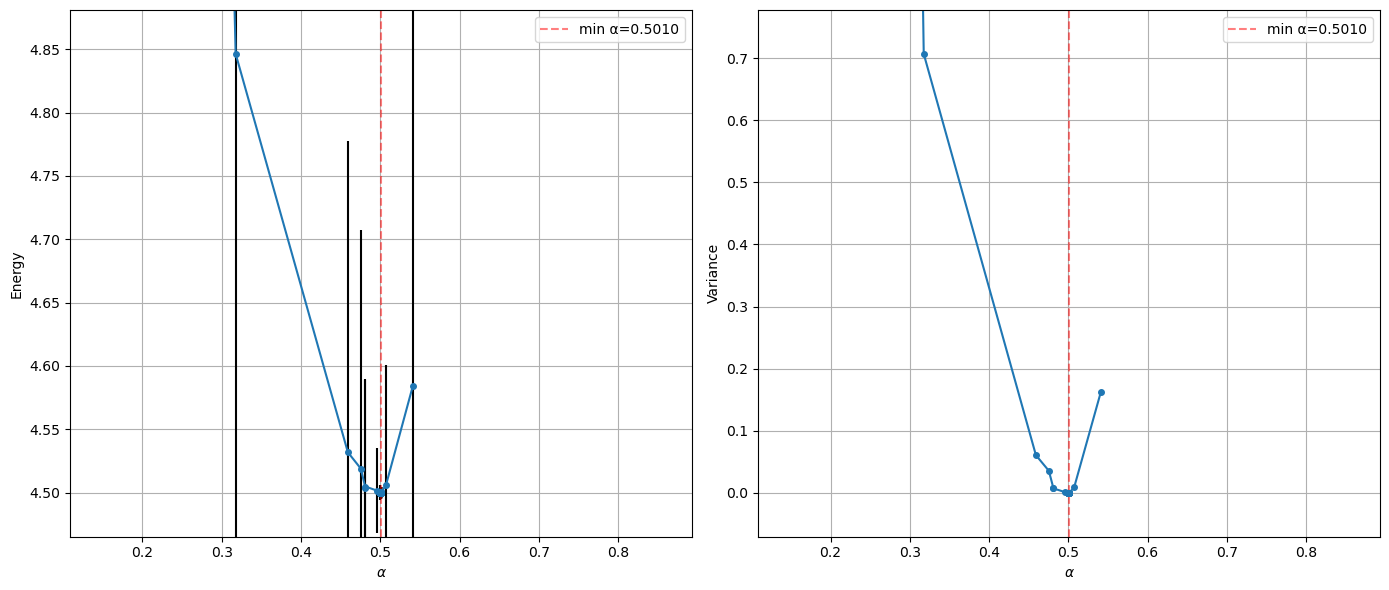

In [8]:
%matplotlib inline

file = np.loadtxt("iofiles/log.csv", delimiter=',')
file = np.transpose(file)
parameters = file[:file.shape[0] - 5, :]
energy = file[file.shape[0] - 5, :]
variance = file[file.shape[0] - 4, :]
error = file[file.shape[0] - 3, :]

# Skip first few iterations
burnin = 2
parameters = parameters[:, burnin:]
energy = energy[burnin:]
variance = variance[burnin:]
error = error[burnin:]

# Sort by alpha
sort_idx = np.argsort(parameters[0, :])
parameters = parameters[:, sort_idx]
energy = energy[sort_idx]
variance = variance[sort_idx]
error = error[sort_idx]

# Find minimum and compute symmetric window around it
min_idx = np.argmin(energy)
min_alpha = parameters[0, min_idx]
max_dist = np.max(np.abs(parameters[0, :] - min_alpha))

# Mask for points within the x window, excluding boundary point
mask = np.abs(parameters[0, :] - min_alpha) < 0.99 * max_dist

fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(1, 2)

ax = fig.add_subplot(gs[0, 0])
ax.errorbar(parameters[0, :], energy, error, ls='-', marker='.', markersize=8, ecolor='black')
ax.axvline(min_alpha, color='red', linestyle='--', alpha=0.5, label=f"min α={min_alpha:.4f}")
ax.set_xlim(min_alpha - max_dist, min_alpha + max_dist)
e_min, e_max = np.min(energy[mask]), np.max(energy[mask])
e_range = e_max - e_min
ax.set_ylim(e_min - 0.1 * e_range, e_max + 0.1 * e_range)
ax.set_ylabel("Energy")
ax.set_xlabel(r"$\alpha$")
ax.legend()

ax = fig.add_subplot(gs[0, 1])
ax.errorbar(parameters[0, :], variance, ls='-', marker='.', markersize=8, ecolor='black')
ax.axvline(min_alpha, color='red', linestyle='--', alpha=0.5, label=f"min α={min_alpha:.4f}")
ax.set_xlim(min_alpha - max_dist, min_alpha + max_dist)
v_min, v_max = np.min(variance[mask]), np.max(variance[mask])
v_range = v_max - v_min
ax.set_ylim(v_min - 0.1 * v_range, v_max + 0.1 * v_range)
ax.set_ylabel("Variance")
ax.set_xlabel(r"$\alpha$")
ax.legend()

plt.tight_layout()
plt.show()

In [6]:
%matplotlib auto

file = np.loadtxt("iofiles/log.csv", delimiter=',')
file = np.transpose(file)
parameters = file[:file.shape[0] - 5, :]
energy = file[file.shape[0] - 5, :]
variance = file[file.shape[0] - 4, :]
error = file[file.shape[0] - 3, :]

# Skip burnin
burnin = 5
parameters = parameters[:, burnin:]
energy = energy[burnin:]
variance = variance[burnin:]
error = error[burnin:]

alpha = parameters[0, :]
beta = parameters[1, :]

fig = plt.figure(figsize=(14, 6))

ax = fig.add_subplot(121, projection='3d')
sc = ax.scatter(alpha, beta, energy, c=energy, cmap='viridis', s=50)
# mark minimum
min_idx = np.argmin(energy)
ax.scatter(alpha[min_idx], beta[min_idx], energy[min_idx], color='red', s=100, zorder=5, label=f"min: α={alpha[min_idx]:.3f}, β={beta[min_idx]:.3f}")
ax.set_xlabel(r"$\alpha$")
ax.set_ylabel(r"$\beta$")
ax.set_zlabel("Energy")
ax.legend()
plt.colorbar(sc, ax=ax, shrink=0.5)

ax = fig.add_subplot(122, projection='3d')
sc = ax.scatter(alpha, beta, variance, c=variance, cmap='viridis', s=50)
ax.scatter(alpha[min_idx], beta[min_idx], variance[min_idx], color='red', s=100, zorder=5, label=f"min: α={alpha[min_idx]:.3f}, β={beta[min_idx]:.3f}")
ax.set_xlabel(r"$\alpha$")
ax.set_ylabel(r"$\beta$")
ax.set_zlabel("Variance")
ax.legend()
plt.colorbar(sc, ax=ax, shrink=0.5)

plt.tight_layout()
plt.show()

Using matplotlib backend: TkAgg
